In [5]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report

# TensorFlow for Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# For measuring execution time
import time

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_excel(r"C:\Users\raipa\OneDrive\Desktop\DL__NN_02\Telco_customer_churn.xlsx")

print(df.head())
print(df.shape)


   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print('Dataset Shape:', df.shape)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [12]:
## Columns to Drop

cols_to_drop = ['CustomerID', 'Count', 'Country', 'State' ,"City" , 
                'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
                'Churn Reason'
                ]

df = df.drop(cols_to_drop,axis=1)

In [13]:
numeric_cols = [
    'Tenure Months', 'Monthly Charges', 'Total Charges' , 'CLTV'
]

In [14]:
cat_columns = [
    'Gender', 'Senior Citizen', 'Partner' , 'Dependents', 'Phone Service', 'Multiple Lines', 
    'Internet Service', 'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method'
]

In [15]:
# Check duplicate records
print('Duplicate Records:', df.duplicated().sum())

Duplicate Records: 0


In [16]:

for columns in df.columns:
    print(columns,":",df[columns].isnull().sum())

Gender : 0
Senior Citizen : 0
Partner : 0
Dependents : 0
Tenure Months : 0
Phone Service : 0
Multiple Lines : 0
Internet Service : 0
Online Security : 0
Online Backup : 0
Device Protection : 0
Tech Support : 0
Streaming TV : 0
Streaming Movies : 0
Contract : 0
Paperless Billing : 0
Payment Method : 0
Monthly Charges : 0
Total Charges : 0
Churn Label : 0
Churn Value : 0
Churn Score : 0
CLTV : 0


In [17]:
# Using .astype(str) protects the encoder from hitting unexpected data types
label_encoder = LabelEncoder()

for column in cat_columns:
    df[column] = label_encoder.fit_transform(df[column].astype(str))

# Print verified structures
print("Data types after transformation:")
print(df.dtypes.head(10))

Data types after transformation:
Gender              int64
Senior Citizen      int64
Partner             int64
Dependents          int64
Tenure Months       int64
Phone Service       int64
Multiple Lines      int64
Internet Service    int64
Online Security     int64
Online Backup       int64
dtype: object


In [18]:
cols_to_scale = ["Monthly Charges", "Total Charges", "CLTV"]

for cols in cols_to_scale:
    df[cols] = pd.to_numeric(df[cols].replace(" ",np.nan))

scaler = StandardScaler()


df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
0,1,0,0,0,2,1,0,0,2,2,...,0,0,1,3,-0.362660,-0.959649,Yes,1,86,-0.981675
1,0,0,0,1,2,1,0,1,0,0,...,0,0,1,2,0.197365,-0.940457,Yes,1,67,-1.436462
2,0,0,0,1,8,1,2,1,0,0,...,2,0,1,2,1.159546,-0.645369,Yes,1,86,0.821409
3,0,0,1,1,28,1,2,1,0,0,...,2,0,1,2,1.330711,0.336516,Yes,1,84,0.509483
4,1,0,0,1,49,1,2,1,0,2,...,2,0,1,0,1.294151,1.214589,Yes,1,89,0.794358


In [19]:
## Separate Features and Target

df_clean = df.dropna()
features = df_clean.drop(['Churn Label',
       'Churn Value', 'Churn Score'] , axis=1)

target = df_clean["Churn Value"]

In [20]:
## Train test set
x_train, x_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [21]:
## Experimenting different ML Models

results = []

def evaluate_model(model_name, model, x_train, x_test, y_train, y_test):

    # Measure training time
    start_train = time.time()
    model.fit(x_train, y_train)
    end_train = time.time()

    # Measure prediction time
    start_pred = time.time()
    y_pred = model.predict(x_test)
    end_pred = time.time()

    # Handle probability predictions
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(x_test)[:, 1]
    else:
        y_prob = y_pred

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Save results
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'Training Time (s)': round(end_train - start_train, 4),
        'Prediction Time (s)': round(end_pred - start_pred, 4)
    })

In [22]:
# Logistic Regression

lr_model = LogisticRegression(max_iter=1000)

evaluate_model(
    'Logistic Regression',
    lr_model,
    x_train,
    x_test,
    y_train,
    y_test
)

In [23]:
# Decision Tree Classifier


dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

evaluate_model(
    'Decision Tree',
    dt_model,
    x_train,
    x_test,
    y_train,
    y_test
)

In [24]:

# Random Forest Classifier


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

evaluate_model(
    'Random Forest',
    rf_model,
    x_train,
    x_test,
    y_train,
    y_test
)

In [25]:
# Support Vector Machine

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

evaluate_model(
    'Support Vector Machine',
    svm_model,
    x_train,
    x_test,
    y_train,
    y_test
)

In [26]:
## ANN model

model = Sequential(
    [
        Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
start_train = time.time()

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

end_train = time.time()

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7264 - loss: 0.6770 - val_accuracy: 0.8133 - val_loss: 0.4213
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7764 - loss: 0.4910 - val_accuracy: 0.8178 - val_loss: 0.3966
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7889 - loss: 0.4607 - val_accuracy: 0.8133 - val_loss: 0.3965
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7862 - loss: 0.4465 - val_accuracy: 0.8169 - val_loss: 0.3913
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7922 - loss: 0.4330 - val_accuracy: 0.8196 - val_loss: 0.3863
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7940 - loss: 0.4261 - val_accuracy: 0.8249 - val_loss: 0.3855
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7947 - loss: 0.4273 - val_accuracy: 0.8204 - val_loss: 0.3834
Epoch 8/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7991 - loss: 0.4188 - val_accuracy: 0.

In [30]:
training_time = end_train - start_train

# Predict using Deep Learning model


start_pred = time.time()

y_prob_dl = model.predict(x_test)

end_pred = time.time()

prediction_time = end_pred - start_pred

# Convert probabilities to class labels
y_pred_dl = (y_prob_dl > 0.5).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_dl)
precision = precision_score(y_test, y_pred_dl)
recall = recall_score(y_test, y_pred_dl)
f1 = f1_score(y_test, y_pred_dl)
roc_auc = roc_auc_score(y_test, y_prob_dl)

# Store results
results.append({
    'Model': 'Deep Neural Network',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'ROC-AUC': roc_auc,
    'Training Time (s)': round(training_time, 4),
    'Prediction Time (s)': round(prediction_time, 4)
})

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


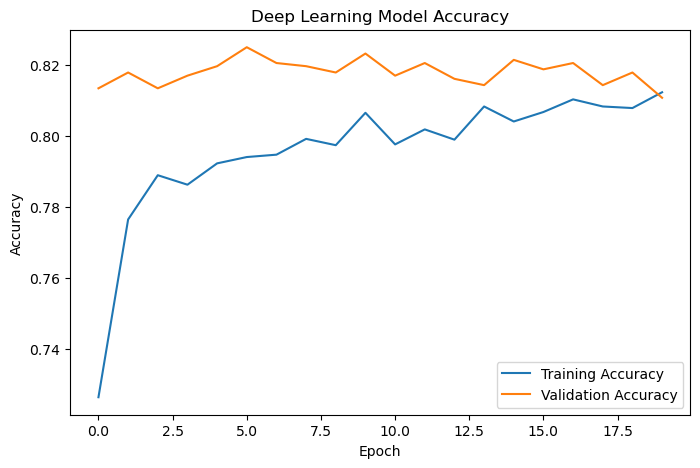

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Deep Learning Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

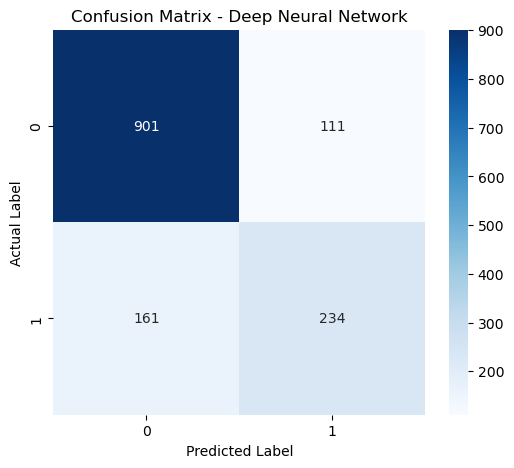

In [32]:
cm = confusion_matrix(y_test, y_pred_dl)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix - Deep Neural Network')

plt.xlabel('Predicted Label')

plt.ylabel('Actual Label')

plt.show()

In [33]:
## Create Performance Comparison Table


results_df = pd.DataFrame(results)

# Display comparison table
print('===== Model Performance Comparison =====')

print(results_df.sort_values(by='Accuracy', ascending=False))

===== Model Performance Comparison =====
                    Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
1           Decision Tree  0.809524   0.747082  0.486076  0.588957  0.849390   
0     Logistic Regression  0.808102   0.689970  0.574684  0.627072  0.861510   
2           Random Forest  0.807392   0.703947  0.541772  0.612303  0.849067   
4     Deep Neural Network  0.806681   0.678261  0.592405  0.632432  0.859791   
3  Support Vector Machine  0.801706   0.747863  0.443038  0.556439  0.826527   

   Training Time (s)  Prediction Time (s)  
1             0.0322               0.0039  
0             0.1605               0.0020  
2             0.5738               0.0207  
4             9.8424               0.2643  
3             5.6170               0.4569  


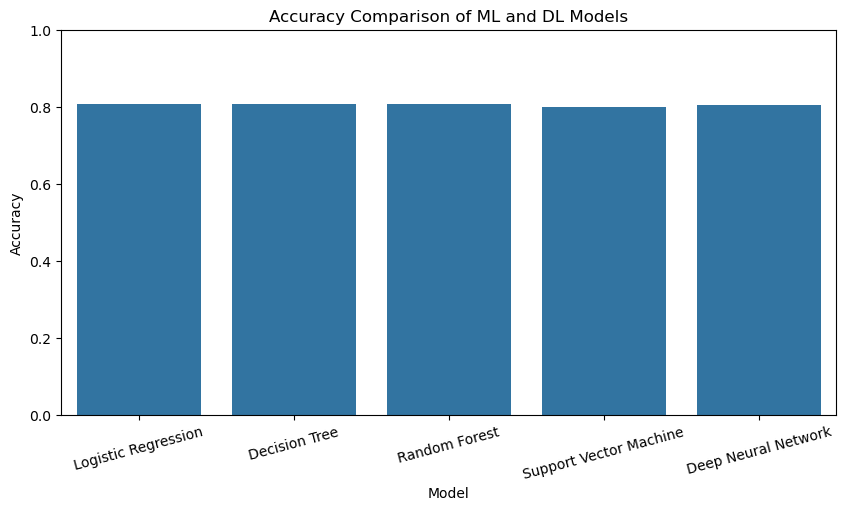

In [34]:
## Visualize Accuracy Comparison

plt.figure(figsize=(10, 5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)

plt.xticks(rotation=15)

plt.title('Accuracy Comparison of ML and DL Models')

plt.ylim(0, 1)

plt.show()

In [35]:
## Save Comparison Report

results_df.to_csv(
    'model_comparison_results.csv',
    index=False
)

print('Comparison report saved successfully.')

Comparison report saved successfully.
